In [110]:
import pandas as pd

# Path relative to the project root
df = pd.read_csv("crop_data..csv")
df.head()


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,ANDAMAN AND NICOBAR,NICOBAR ISLANDS,2000,Kharif,Arecanut,1254.0,2000.0
1,ANDAMAN AND NICOBAR,NICOBAR ISLANDS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,ANDAMAN AND NICOBAR,NICOBAR ISLANDS,2000,Kharif,Rice,102.0,321.0
3,ANDAMAN AND NICOBAR,NICOBAR ISLANDS,2000,Whole Year,Banana,176.0,641.0
4,ANDAMAN AND NICOBAR,NICOBAR ISLANDS,2000,Whole Year,Cashewnut,720.0,165.0


In [111]:
# Check for nulls
print(df.isnull().sum())

# Fill or drop missing values (Production often has nulls)
df = df.dropna().copy()

# Add a Yield column
df['Yield'] = df['Production'] / df['Area']
df.head()


State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield
0,ANDAMAN AND NICOBAR,NICOBAR ISLANDS,2000,Kharif,Arecanut,1254.0,2000.0,1.594896
1,ANDAMAN AND NICOBAR,NICOBAR ISLANDS,2000,Kharif,Other Kharif pulses,2.0,1.0,0.500000
2,ANDAMAN AND NICOBAR,NICOBAR ISLANDS,2000,Kharif,Rice,102.0,321.0,3.147059
3,ANDAMAN AND NICOBAR,NICOBAR ISLANDS,2000,Whole Year,Banana,176.0,641.0,3.642045
4,ANDAMAN AND NICOBAR,NICOBAR ISLANDS,2000,Whole Year,Cashewnut,720.0,165.0,0.229167


In [112]:
top_states = df.groupby("State_Name")["Production"].sum().sort_values(ascending=False)

top_states.head(10)

State_Name
Kerala                 9.788005e+10
Andhra Pradesh         1.732459e+10
Tamil Nadu             1.207644e+10
Uttar Pradesh          3.234493e+09
Assam                  2.111752e+09
West Bengal            1.397904e+09
Maharashtra            1.263641e+09
Karnataka              8.634298e+08
ANDAMAN AND NICOBAR    7.182232e+08
Punjab                 5.863850e+08
Name: Production, dtype: float64

Crop
Coconut         1.299816e+11
Sugarcane       5.535682e+09
Rice            1.605470e+09
Wheat           1.332826e+09
Potato          4.248263e+08
Cotton(lint)    2.970000e+08
Maize           2.733418e+08
Jute            1.815582e+08
Banana          1.461327e+08
Soyabean        1.418372e+08
Name: Production, dtype: float64

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

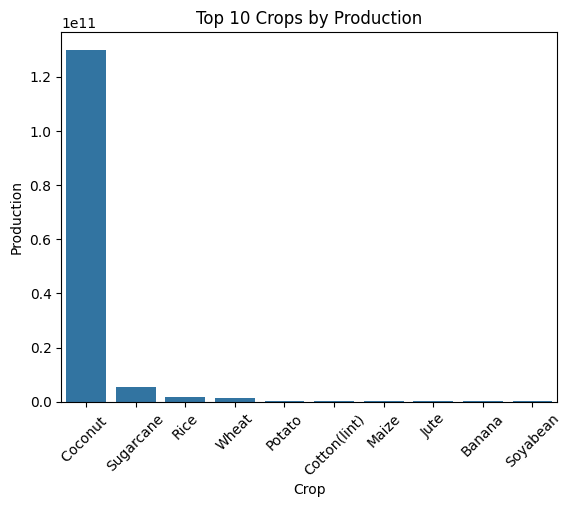

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

top_crops = df.groupby("Crop")["Production"].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_crops.index, y=top_crops.values)

plt.title("Top 10 Crops by Production")
plt.xlabel("Crop")
plt.ylabel("Production")
plt.xticks(rotation=45)
plt.show()

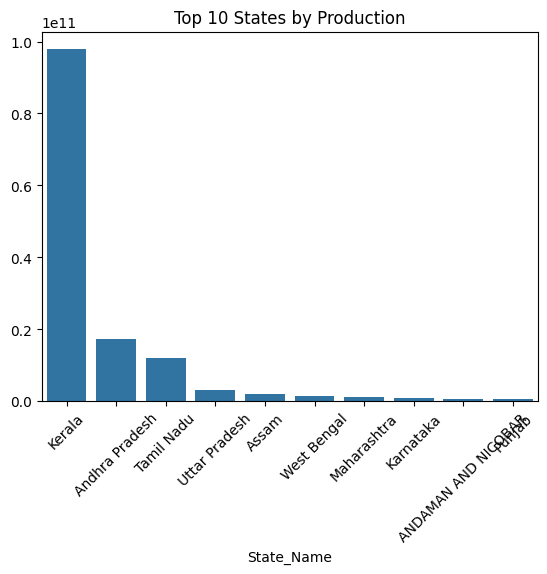

In [118]:
top_states = df.groupby("State_Name")["Production"].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_states.index, y=top_states.values)

plt.title("Top 10 States by Production")
plt.xticks(rotation=45)
plt.show()

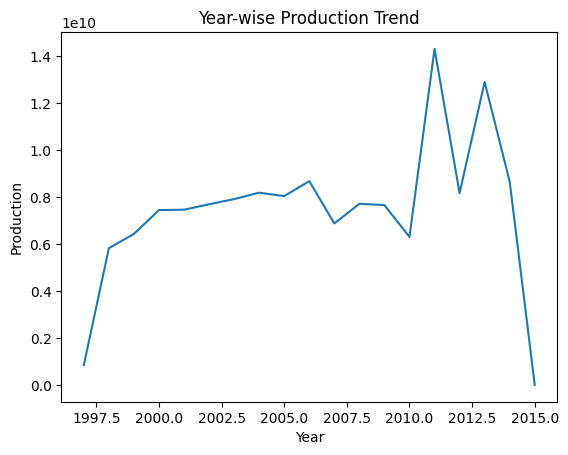

In [119]:
year_trend = df.groupby("Crop_Year")["Production"].sum()

year_trend.plot()

plt.title("Year-wise Production Trend")
plt.xlabel("Year")
plt.ylabel("Production")
plt.show()